In [1]:
!pip install -q transformers==4.44.2 sentencepiece bert-score
!pip install -q peft==0.12.0 accelerate bitsandbytes
!pip install -q matplotlib pandas numpy tqdm nltk wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 129.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.6 MB/s eta 0:00:00


In [2]:
import os, time, random, re, unicodedata, shutil, gc, warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='Some weights')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
from bert_score import score as bert_score_fn
import wandb

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {DEVICE}')
if DEVICE.type == 'cuda':
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'{torch.cuda.get_device_name(0)} | {gpu_mem:.1f} GB')

Using: cuda
Tesla T4 | 15.6 GB


[nltk_data] Error downloading 'punkt_tab' from
[nltk_data]     <https://raw.githubusercontent.com/nltk/nltk_data/gh-
[nltk_data]     pages/packages/tokenizers/punkt_tab.zip>:   HTTP Error
[nltk_data]     429: Too Many Requests


In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_CKPT = '/content/drive/MyDrive/sanskrit_nmt_ckpts'
    os.makedirs(DRIVE_CKPT, exist_ok=True)
    HAS_DRIVE = True
    print(f'Drive checkpoints: {DRIVE_CKPT}')
except:
    DRIVE_CKPT = './checkpoints'
    os.makedirs(DRIVE_CKPT, exist_ok=True)
    HAS_DRIVE = False
    print('No Drive — local checkpoints')

Mounted at /content/drive
Drive checkpoints: /content/drive/MyDrive/sanskrit_nmt_ckpts


In [4]:
wandb.login()
run = wandb.init(
    project='sanskrit-nmt', name='nllb-lora-r32-aug',
    resume='allow', id='nllb_lora_v3',
    config={'model': 'nllb-200-distilled-600M', 'lora_r': 32, 'lora_alpha': 64,
            'lr': 3e-4, 'epochs': 15, 'batch_size': 8, 'grad_accum': 8,
            'label_smoothing': 0.1, 'num_beams': 4, 'augmentation': 'word_dropout+swap'}
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: m22ph203 (m22ph203-indian-institute-of-technology-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
class CFG:
    model_name     = 'facebook/nllb-200-distilled-600M'
    src_lang       = 'san_Deva'
    tgt_lang       = 'eng_Latn'
    max_src_len    = 128
    max_tgt_len    = 128   # training target length
    max_gen_len    = 80    # inference generation length (99% of EN is <40 words, subwords ~1.3x)
    batch_size     = 8
    grad_accum     = 8
    epochs         = 18
    lr             = 3e-4
    warmup_ratio   = 0.06
    label_smooth   = 0.1
    patience       = 4
    lora_r         = 32
    lora_alpha     = 64
    lora_dropout   = 0.05
    num_beams      = 2
    length_penalty = 1.0
    no_repeat_ngram = 3
    repetition_penalty = 1.2
    word_dropout   = 0.1   # augmentation: drop 10% of source words during training
    word_swap_prob = 0.1   # augmentation: swap adjacent words 10% of the time
    data_dir       = './data'
    ckpt_dir       = DRIVE_CKPT

os.makedirs(CFG.data_dir, exist_ok=True)

In [6]:
def clean_text(text):
    if not isinstance(text, str): return ''
    text = unicodedata.normalize('NFC', text)
    text = text.replace('\ufeff', '').replace('\u200b', '').replace('\u200c', '')
    text = re.sub(r'\s+', ' ', text).strip()
    if text.startswith('"') and text.endswith('"') and text.count('"') == 2:
        text = text[1:-1].strip()
    return text


def load_pairs(split):
    suffix = '10000' if split == 'train' else '1000'
    sa = pd.read_csv(f'{CFG.data_dir}/{split}_sa_{suffix}.csv', encoding='utf-8-sig')
    en = pd.read_csv(f'{CFG.data_dir}/{split}_en_{suffix}.csv', encoding='utf-8-sig')
    sa.columns = sa.columns.str.strip()
    en.columns = en.columns.str.strip()
    df = sa.merge(en, on='Source_id')
    df['Sentence_sa'] = df['Sentence_sa'].apply(clean_text)
    df['Sentence_en'] = df['Sentence_en'].apply(clean_text)
    df = df[(df['Sentence_sa'].str.len() > 2) & (df['Sentence_en'].str.len() > 2)]
    return df.drop_duplicates(subset=['Sentence_sa', 'Sentence_en']).reset_index(drop=True)


def augment_source(text, drop_prob=0.1, swap_prob=0.1):
    """Source-side noise injection for robustness.
    Word dropout: randomly drop words to teach the model to handle incomplete input.
    Word swap: swap adjacent words to handle word order variation in Sanskrit."""
    words = text.split()
    if len(words) <= 2:
        return text
    # word dropout
    words = [w for w in words if random.random() > drop_prob]
    if not words:
        words = text.split()  # safety: don't drop everything
    # adjacent swap
    for i in range(len(words) - 1):
        if random.random() < swap_prob:
            words[i], words[i+1] = words[i+1], words[i]
    return ' '.join(words)


for fname in ['dev_en_1000.csv', 'dev_sa_1000.csv', 'test_en_1000.csv',
              'test_sa_1000.csv', 'train_en_10000.csv', 'train_sa_10000.csv']:
    for src_dir in ['/content', '.']:
        s = os.path.join(src_dir, fname)
        d = os.path.join(CFG.data_dir, fname)
        if os.path.exists(s) and not os.path.exists(d):
            shutil.copy(s, d); break

train_df = load_pairs('train')
dev_df   = load_pairs('dev')
test_df  = load_pairs('test')
print(f'Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}')

# show augmentation example
sample = train_df.iloc[2]['Sentence_sa']
print(f'\nOriginal:  {sample}')
print(f'Augmented: {augment_source(sample, 0.1, 0.1)}')
print(f'Augmented: {augment_source(sample, 0.1, 0.1)}')

Train: 9981 | Dev: 1000 | Test: 1000

Original:  चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित्रद्वयं स्वीकरणीयमस्ति । इदमतीव सुलभमस्ति ।
Augmented: कर्तुं चित्रचालनमिदं मया अस्याः राशेः चित्रद्वयं । । सुलभमस्ति
Augmented: चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः । इदमतीव सुलभमस्ति ।


In [8]:
tokenizer = AutoTokenizer.from_pretrained(
    CFG.model_name, src_lang=CFG.src_lang, tgt_lang=CFG.tgt_lang,
    clean_up_tokenization_spaces=True
)
TGT_LANG_ID = tokenizer.convert_tokens_to_ids(CFG.tgt_lang)
print(f'Vocab: {len(tokenizer)} | Target id: {TGT_LANG_ID}')

Vocab: 256204 | Target id: 256047


In [9]:
class TranslationDataset(Dataset):
    def __init__(self, df, max_src, max_tgt, augment=False):
        self.src = df['Sentence_sa'].tolist()
        self.tgt = df['Sentence_en'].tolist()
        self.max_src, self.max_tgt = max_src, max_tgt
        self.augment = augment

    def __len__(self): return len(self.src)

    def __getitem__(self, i):
        src_text = self.src[i]
        if self.augment:
            src_text = augment_source(src_text, CFG.word_dropout, CFG.word_swap_prob)
        tokenizer.src_lang = CFG.src_lang
        enc = tokenizer(src_text, max_length=self.max_src, truncation=True, padding=False)
        lab = tokenizer(text_target=self.tgt[i], max_length=self.max_tgt, truncation=True, padding=False)['input_ids']
        return {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask'], 'labels': lab}


def collate_fn(batch):
    pad = tokenizer.pad_token_id
    ids  = nn.utils.rnn.pad_sequence([torch.tensor(b['input_ids']) for b in batch], True, pad)
    mask = nn.utils.rnn.pad_sequence([torch.tensor(b['attention_mask']) for b in batch], True, 0)
    labs = nn.utils.rnn.pad_sequence([torch.tensor(b['labels']) for b in batch], True, -100)
    return {'input_ids': ids, 'attention_mask': mask, 'labels': labs}


train_loader = DataLoader(
    TranslationDataset(train_df, CFG.max_src_len, CFG.max_tgt_len, augment=True),
    batch_size=CFG.batch_size, shuffle=True, collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)
print(f'{len(train_loader)} batches (bs={CFG.batch_size}, eff={CFG.batch_size*CFG.grad_accum})')

1248 batches (bs=8, eff=64)


In [11]:
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    CFG.model_name, torch_dtype=torch.float16, tie_word_embeddings=False
).to(DEVICE)

for p in base_model.parameters():
    p.requires_grad = False


lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=CFG.lora_r, lora_alpha=CFG.lora_alpha, lora_dropout=CFG.lora_dropout,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'out_proj', 'fc1', 'fc2'],
    bias='none', inference_mode=False
)
model = get_peft_model(base_model, lora_cfg)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total     = trainable + frozen

print(f'Trainable (LoRA):  {trainable:>12,}')
print(f'Frozen (base):     {frozen:>12,}')
print(f'Total:             {total:>12,}')
print(f'Trainable %:       {100*trainable/total:.2f}%')

wandb.config.update({'trainable_params': trainable, 'frozen_params': frozen, 'total_params': total})

if DEVICE.type == 'cuda':
    print(f'GPU after load: {torch.cuda.memory_allocated()/1e9:.2f} GB')

Trainable (LoRA):    17,301,504
Frozen (base):      877,428,736
Total:              894,730,240
Trainable %:       1.93%
GPU after load: 1.83 GB


In [12]:
class LabelSmoothingCE(nn.Module):
    def __init__(self, eps=0.1, ignore_index=-100):
        super().__init__()
        self.eps, self.ign = eps, ignore_index

    def forward(self, logits, targets):
        lp = F.log_softmax(logits.float(), dim=-1)
        mask = targets != self.ign
        nll = -lp.gather(-1, targets.clamp(min=0).unsqueeze(-1)).squeeze(-1)
        loss = (1 - self.eps) * nll + self.eps * (-lp.mean(-1))
        return loss[mask].mean()

criterion = LabelSmoothingCE(eps=CFG.label_smooth)

In [14]:
def save_checkpoint(epoch, best_bleu, train_losses, val_bleus):
    state = {
        'epoch': epoch, 'best_bleu': best_bleu,
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'train_losses': train_losses, 'val_bleus': val_bleus,
    }
    model.save_pretrained(f'{CFG.ckpt_dir}/lora_last')
    torch.save(state, f'{CFG.ckpt_dir}/train_state.pt')
    if best_bleu == max(val_bleus + [-1]):
        model.save_pretrained(f'{CFG.ckpt_dir}/lora_best')


# check if we can resume
state_path = f'{CFG.ckpt_dir}/train_state.pt'
lora_path  = f'{CFG.ckpt_dir}/lora_last'

start_epoch = 0
best_bleu = -1.0
train_losses = []
val_bleus = []
saved_state = None

if os.path.exists(state_path) and os.path.exists(lora_path):
    model = PeftModel.from_pretrained(base_model, lora_path, is_trainable=True).to(DEVICE)
    for n, p in model.named_parameters():
        if 'lora_' in n: p.requires_grad = True
    saved_state = torch.load(state_path, map_location=DEVICE, weights_only=False)
    start_epoch = saved_state['epoch']
    best_bleu = saved_state['best_bleu']
    train_losses = saved_state['train_losses']
    val_bleus = saved_state['val_bleus']
    print(f'Resumed from epoch {start_epoch}, best_bleu={best_bleu:.2f}')
else:
    print('Starting fresh')

# rebuild optimizer with CURRENT model's params
decay = [p for n, p in model.named_parameters() if p.requires_grad and 'bias' not in n and 'norm' not in n]
no_decay = [p for n, p in model.named_parameters() if p.requires_grad and ('bias' in n or 'norm' in n)]

optimizer = torch.optim.AdamW(
    [{'params': decay, 'weight_decay': 0.01}, {'params': no_decay, 'weight_decay': 0.0}],
    lr=CFG.lr, betas=(0.9, 0.98), eps=1e-8
)

total_steps = (len(train_loader) // CFG.grad_accum) * CFG.epochs
warmup_steps = int(total_steps * CFG.warmup_ratio)
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler = GradScaler('cuda')

# now load optimizer state into the freshly created optimizer
if saved_state is not None:
    optimizer.load_state_dict(saved_state['optimizer'])
    try: scheduler.load_state_dict(saved_state['scheduler'])
    except: pass
    scaler.load_state_dict(saved_state['scaler'])
    del saved_state

print(f'Optimizer ready, starting from epoch {start_epoch+1}')

Starting fresh
Optimizer ready, starting from epoch 1


In [15]:
@torch.no_grad()
def translate_batch(src_texts, num_beams=None):
    nb = num_beams or CFG.num_beams
    tokenizer.src_lang = CFG.src_lang
    inputs = tokenizer(src_texts, return_tensors='pt', padding=True,
                       truncation=True, max_length=CFG.max_src_len).to(DEVICE)
    with autocast('cuda'):
        out = model.generate(
            **inputs, forced_bos_token_id=TGT_LANG_ID,
            num_beams=nb, max_new_tokens=CFG.max_gen_len,
            length_penalty=CFG.length_penalty,
            no_repeat_ngram_size=CFG.no_repeat_ngram,
            repetition_penalty=CFG.repetition_penalty,
            early_stopping=(nb > 1), use_cache=True
        )
    return tokenizer.batch_decode(out, skip_special_tokens=True)


@torch.no_grad()
def compute_bleu(df, batch_size=32, num_beams=1):
    model.eval()
    preds, refs = [], []
    for i in range(0, len(df), batch_size):
        chunk = df.iloc[i:i+batch_size]
        preds.extend(translate_batch(chunk['Sentence_sa'].tolist(), num_beams=num_beams))
        refs.extend(chunk['Sentence_en'].tolist())
    bleu = corpus_bleu([[r.split()] for r in refs], [h.split() for h in preds]) * 100
    return bleu, preds, refs

In [16]:
patience_cnt = 0

for epoch in range(start_epoch, CFG.epochs):
    model.train()
    epoch_loss = []
    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Epoch {epoch+1}/{CFG.epochs}')

    for step, batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with autocast('cuda'):
            # use the model's built-in loss — works with gradient checkpointing
            loss = model(**batch).loss / CFG.grad_accum

        scaler.scale(loss).backward()
        epoch_loss.append(loss.item() * CFG.grad_accum)

        if (step + 1) % CFG.grad_accum == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if step % 50 == 0:
            wandb.log({'train_loss_step': np.mean(epoch_loss[-50:]), 'lr': scheduler.get_last_lr()[0]})
        pbar.set_postfix(loss=f'{np.mean(epoch_loss[-50:]):.4f}')

    avg_loss = np.mean(epoch_loss)
    train_losses.append(avg_loss)
    torch.cuda.empty_cache()

    val_bleu, _, _ = compute_bleu(dev_df, batch_size=16, num_beams=1)
    val_bleus.append(val_bleu)

    wandb.log({'epoch': epoch+1, 'train_loss': avg_loss, 'dev_bleu': val_bleu, 'best_bleu': best_bleu})
    print(f'  loss={avg_loss:.4f} | dev_bleu={val_bleu:.2f} | best={best_bleu:.2f}')

    if val_bleu > best_bleu:
        best_bleu = val_bleu
        patience_cnt = 0
    else:
        patience_cnt += 1

    save_checkpoint(epoch + 1, best_bleu, train_losses, val_bleus)

    if DEVICE.type == 'cuda':
        print(f'  GPU: {torch.cuda.memory_allocated()/1e9:.1f}/{torch.cuda.max_memory_allocated()/1e9:.1f} GB')

    if patience_cnt >= CFG.patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

print(f'Best dev BLEU: {best_bleu:.2f}')

Epoch 1/18:   0%|          | 0/1248 [00:00<?, ?it/s]

  loss=2.2909 | dev_bleu=17.37 | best=-1.00
  GPU: 2.0/6.8 GB


Epoch 2/18:   0%|          | 0/1248 [00:00<?, ?it/s]

  loss=1.9754 | dev_bleu=19.83 | best=17.37
  GPU: 2.0/6.8 GB


Epoch 3/18:   0%|          | 0/1248 [00:00<?, ?it/s]

...

  loss=1.2819 | dev_bleu=23.23 | best=23.30
  GPU: 2.0/6.8 GB


Epoch 17/18:   0%|          | 0/1248 [00:00<?, ?it/s]

  loss=1.2796 | dev_bleu=23.61 | best=23.30
  GPU: 2.0/6.8 GB


Epoch 18/18:   0%|          | 0/1248 [00:00<?, ?it/s]

  loss=1.2803 | dev_bleu=23.56 | best=23.61
  GPU: 2.0/6.8 GB
Best dev BLEU: 23.61


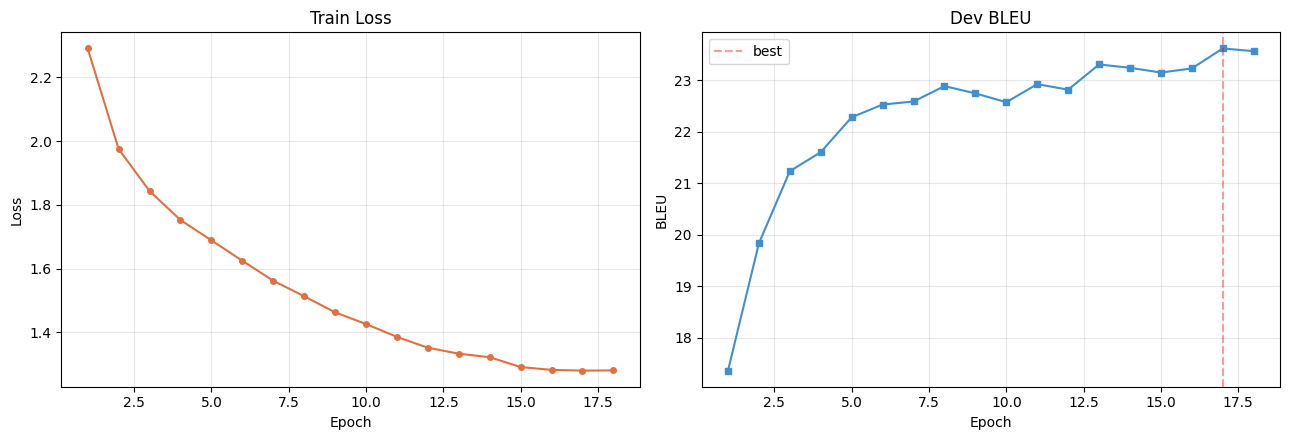

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ep = range(1, len(train_losses)+1)
ax1.plot(ep, train_losses, 'o-', color='#e07040', ms=4)
ax1.set(title='Train Loss', xlabel='Epoch', ylabel='Loss'); ax1.grid(alpha=0.3)
ax2.plot(ep, val_bleus, 's-', color='#4090d0', ms=4)
ax2.axvline(np.argmax(val_bleus)+1, color='red', ls='--', alpha=0.4, label='best')
ax2.set(title='Dev BLEU', xlabel='Epoch', ylabel='BLEU'); ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout(); plt.savefig('training_curves.png', dpi=120)
wandb.log({'training_curves': wandb.Image('training_curves.png')})
plt.show()

In [18]:
del model; gc.collect(); torch.cuda.empty_cache()

base_eval = AutoModelForSeq2SeqLM.from_pretrained(
    CFG.model_name, torch_dtype=torch.float16, tie_word_embeddings=False
).to(DEVICE)
peft_model = PeftModel.from_pretrained(base_eval, f'{CFG.ckpt_dir}/lora_best').to(DEVICE)

# merge LoRA weights into base model — eliminates adapter overhead at inference
# this makes forward pass faster since there's no separate LoRA computation
model = peft_model.merge_and_unload()
model.eval()

# param counts — use the saved values from training since merged model has no LoRA distinction
LORA_PARAMS = sum(p.numel() for n, p in peft_model.named_parameters() if 'lora_' in n) if hasattr(peft_model, 'named_parameters') else trainable
print(f'Loaded best checkpoint and merged LoRA weights')
print(f'Model ready for fast inference')

Loaded best checkpoint and merged LoRA weights
Model ready for fast inference


In [19]:
sweep_df = dev_df.sample(200, random_state=42)
for nb in [1, 2, 4]:
    t0 = time.time()
    b, _, _ = compute_bleu(sweep_df, batch_size=16, num_beams=nb)
    print(f'beams={nb} | BLEU={b:.2f} | {time.time()-t0:.1f}s')

beams=1 | BLEU=22.94 | 16.0s
beams=2 | BLEU=26.10 | 16.9s
beams=4 | BLEU=26.92 | 20.5s


In [20]:
dev_bleu, dev_preds, dev_refs = compute_bleu(dev_df, batch_size=16, num_beams=CFG.num_beams)
P, R, F1 = bert_score_fn(dev_preds, dev_refs, lang='en', rescale_with_baseline=True, verbose=True)
dev_bert = F1.mean().item()
print(f'Dev BLEU: {dev_bleu:.2f} | BERTScore: {dev_bert:.4f}')
wandb.log({'dev_bleu_final': dev_bleu, 'dev_bert_f1': dev_bert})

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/31 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 9.75 seconds, 102.53 sentences/sec
Dev BLEU: 26.15 | BERTScore: 0.6106


In [21]:
test_preds = []
_ = translate_batch(test_df.iloc[:2]['Sentence_sa'].tolist())
torch.cuda.synchronize()

t0 = time.time()
for i in tqdm(range(0, len(test_df), 16), desc='Test'):
    test_preds.extend(translate_batch(test_df.iloc[i:i+16]['Sentence_sa'].tolist()))
torch.cuda.synchronize()
inf_time = time.time() - t0

total_params = sum(p.numel() for p in model.parameters())

print(f'Inference: {inf_time:.2f}s ({len(test_df)/inf_time:.1f} sent/s)')
print(f'\nParameters:')
print(f'  Total:             {total_params:>12,}')

Test:   0%|          | 0/63 [00:00<?, ?it/s]

Inference: 83.22s (12.0 sent/s)

Parameters:
  Total:              877,428,736


In [22]:
test_refs = test_df['Sentence_en'].tolist()
test_bleu = corpus_bleu([[r.split()] for r in test_refs], [h.split() for h in test_preds]) * 100
_, _, F1_test = bert_score_fn(test_preds, test_refs, lang='en', rescale_with_baseline=True, verbose=True)
test_bert = F1_test.mean().item()
print(f'Test BLEU: {test_bleu:.2f} | BERTScore: {test_bert:.4f}')
wandb.log({'test_bleu': test_bleu, 'test_bert_f1': test_bert, 'inference_time': inf_time})

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/31 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 11.54 seconds, 86.68 sentences/sec
Test BLEU: 25.06 | BERTScore: 0.6113


In [23]:
submission = pd.DataFrame({'Source_id': test_df['Source_id'].tolist(), 'Sentence_en': test_preds})
submission.to_csv('submission.csv', index=False, encoding='utf-8')
if HAS_DRIVE:
    submission.to_csv(f'{CFG.ckpt_dir}/submission.csv', index=False, encoding='utf-8')
print('Saved submission.csv')
submission.head(10)

Saved submission.csv


,Source_id,Sentence_en
0,1,Eclipse helps in troubleshooting the program.
1,2,"And they say, We have faith by faith: as it is..."
2,3,Then it will search for the driver on its own....
3,4,"This means that for all iterations, the iterat..."
4,5,"And when he had opened the second seal, I hear..."
5,6,We have learnt that objects store their positi...
6,7,Child has trust in you all.
7,8,You may be amazed to observe the nature.
8,9,"And his affection overfloweth toward you, when..."
9,10,Some parts of water from rain get dried and ge...


In [24]:
sample = test_df.iloc[:10].reset_index(drop=True)
hyps = test_preds[:10]
refs = sample['Sentence_en'].tolist()
_, _, f1s = bert_score_fn(hyps, refs, lang='en', rescale_with_baseline=True, verbose=False)

for i in range(10):
    sb = sentence_bleu([refs[i].split()], hyps[i].split()) * 100
    print(f'\n[{i+1}] SA:  {sample.iloc[i]["Sentence_sa"][:90]}')
    print(f'    REF: {refs[i][:90]}')
    print(f'    HYP: {hyps[i][:90]}')
    print(f'    BLEU={sb:.1f}  BERT={f1s[i].item():.3f}')

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[1] SA:  एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।
    REF: Eclipse also helps the programmer to find out errors.
    HYP: Eclipse helps in troubleshooting the program.
    BLEU=0.0  BERT=0.560

[2] SA:  विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजनकम् आत्मान
    REF: We having the same spirit of faith, according as it is written, I believed, and therefore 
    HYP: And they say, We have faith by faith: as it is written, We also receive the Spirit of fait
    BLEU=13.4  BERT=0.270

[3] SA:  तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं 'Cancel' इत्यस्योपरि नुदामि।
    REF: Then it will automatically begin searching for drivers. I will click on Cancel.
    HYP: Then it will search for the driver on its own. I will click on Cancel.
    BLEU=33.9  BERT=0.801

[4] SA:  सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्येकस्मै इण्डेक्स्-वेल्यू-इत्यस्मै सेट् क्रिय
    REF: The iterator will be set to each of the indices values for each it

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

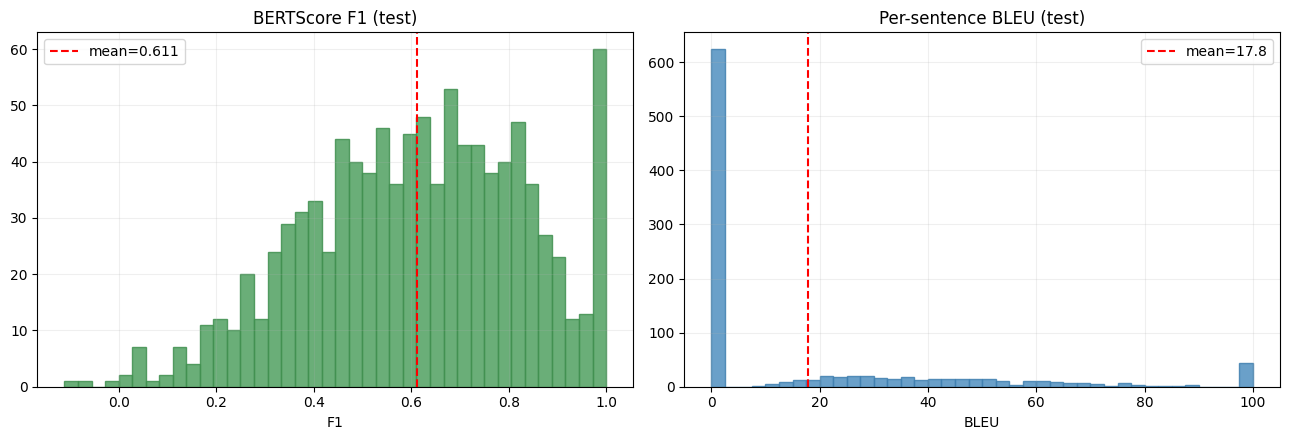

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
f1arr = F1_test.numpy()
ax1.hist(f1arr, bins=40, color='#50a060', edgecolor='#40904f', alpha=0.85)
ax1.axvline(f1arr.mean(), color='red', ls='--', lw=1.5, label=f'mean={f1arr.mean():.3f}')
ax1.set(title='BERTScore F1 (test)', xlabel='F1'); ax1.legend(); ax1.grid(alpha=0.2)
pbleus = [sentence_bleu([r.split()], h.split())*100 for r, h in zip(test_refs, test_preds)]
ax2.hist(pbleus, bins=40, color='#5090c0', edgecolor='#4080b0', alpha=0.85)
ax2.axvline(np.mean(pbleus), color='red', ls='--', lw=1.5, label=f'mean={np.mean(pbleus):.1f}')
ax2.set(title='Per-sentence BLEU (test)', xlabel='BLEU'); ax2.legend(); ax2.grid(alpha=0.2)
plt.tight_layout(); plt.savefig('score_distributions.png', dpi=120)
wandb.log({'score_distributions': wandb.Image('score_distributions.png')})
plt.show()

In [26]:
print('=' * 50)
print('RESULTS')
print('=' * 50)
results = {
    'Dev BLEU': f'{dev_bleu:.2f}',
    'Test BLEU': f'{test_bleu:.2f}',
    'Dev BERTScore F1': f'{dev_bert:.4f}',
    'Test BERTScore F1': f'{test_bert:.4f}',
    'Inference time': f'{inf_time:.2f}s',
    'Total params': f'{total_params:,}',
    'Beam size': str(CFG.num_beams),
    'Epochs trained': str(len(train_losses)),
}
for k, v in results.items():
    print(f'  {k:<22} {v}')
print('=' * 50)
wandb.summary.update(results)
wandb.finish()
print('Done')

RESULTS
  Dev BLEU               26.15
  Test BLEU              25.06
  Dev BERTScore F1       0.6106
  Test BERTScore F1      0.6113
  Inference time         83.22s
  Total params           877,428,736
  Beam size              2
  Epochs trained         18


best_bleu,▁▆▇▇▇█████████████
dev_bert_f1,▁
dev_bleu,▁▄▅▆▇▇▇▇▇▇▇▇██▇███
dev_bleu_final,▁
epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
inference_time,▁
lr,▂▃▄▄████████▇▇▇▆▆▆▆▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▁▁▁
test_bert_f1,▁
test_bleu,▁
train_loss,█▆▅▄▄▃▃▃▂▂▂▁▁▁▁▁▁▁
+1,...


Done
